In [65]:
from pathlib import Path

import pandas as pd

# Data loading

In [66]:
DATA_DIR = Path("../results")
file_name = "SingleMachineProblem_2025-04-19_14-32-51.csv"
# file_name = "ParallelMachineProblem_2025-04-19_09-03-22.csv"
# file_name = "HybridFlowShop_2025-04-19_09-02-55.csv"
# file_name = "ParallelMachineProblem_2025-04-16_20-54-36.csv"
# file_name = "HybridFlowShop_2025-04-16_20-54-04.csv"
# file_name = "ParallelMachineProblem_2025-04-18_11-36-42.csv"
# file_name = "HybridFlowShop_2025-04-18_11-37-13.csv"
df = pd.read_csv(DATA_DIR / file_name)
# print(df.head(10))
df[df.simheuristic == "det_opt"]

,project_name,problem_type,simheuristic,seed,mean,std,num_sims,DCOP_objective,callback_log,solve status,solution,solver_phase_dur,final_sim_phase_dur,total_exp_dur
0,SingleMachineProblem_2025-04-19_14-32-51,SingleMachineProblem,det_opt,0,366.456853,519.148575,394,49.0,\nCallback Log:\n-----------------------------...,Optimal,"{""tasks"": [{""mode"": 0, ""resources"": [0], ""star...",0.071108,4.937463,5.008571
1,SingleMachineProblem_2025-04-19_14-32-51,SingleMachineProblem,det_opt,1,366.344913,516.820479,403,49.0,\nCallback Log:\n-----------------------------...,Optimal,"{""tasks"": [{""mode"": 0, ""resources"": [0], ""star...",0.091950,4.916766,5.008716
2,SingleMachineProblem_2025-04-19_14-32-51,SingleMachineProblem,det_opt,2,368.675481,525.374819,416,49.0,\nCallback Log:\n-----------------------------...,Optimal,"{""tasks"": [{""mode"": 0, ""resources"": [0], ""star...",0.060596,4.945557,5.006152
3,SingleMachineProblem_2025-04-19_14-32-51,SingleMachineProblem,det_opt,3,362.129584,514.262075,409,49.0,\nCallback Log:\n-----------------------------...,Optimal,"{""tasks"": [{""mode"": 0, ""resources"": [0], ""star...",0.074917,4.927918,5.002836
4,SingleMachineProblem_2025-04-19_14-32-51,SingleMachineProblem,det_opt,4,365.333333,524.219636,426,49.0,\nCallback Log:\n-----------------------------...,Optimal,"{""tasks"": [{""mode"": 0, ""resources"": [0], ""star...",0.237615,4.765079,5.002694


# Summary statistics

In [67]:
# Convert numeric columns to proper types (in case they were read as strings)
numeric_cols = [
    "mean",
    "num_sims",
    "DCOP_objective",
    "solver_phase_dur",
    "final_sim_phase_dur",
    "total_exp_dur",
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Group by simheuristic and take the mean of selected columns
agg_results = df.groupby("simheuristic")[numeric_cols].mean().round(2)

# Count number of feasible experiments per simheuristic
feasible_counts = (
    df[df["solve status"] == "Feasible"]
    .groupby("simheuristic")
    .size()
    .rename("num_feasible")
)

# Merge aggregated stats with feasible count
summary = agg_results.merge(
    feasible_counts, on="simheuristic", how="left"
).fillna(0)

# Show nicely in notebook
summary.style.set_caption(f"Summary per Simheuristic for {file_name}")

,mean,num_sims,DCOP_objective,solver_phase_dur,final_sim_phase_dur,total_exp_dur,num_feasible
simheuristic,,,,,,,
det_opt,365.790000,409.600000,49.000000,0.110000,4.900000,5.010000,0.000000


# Detailed results scatterplot

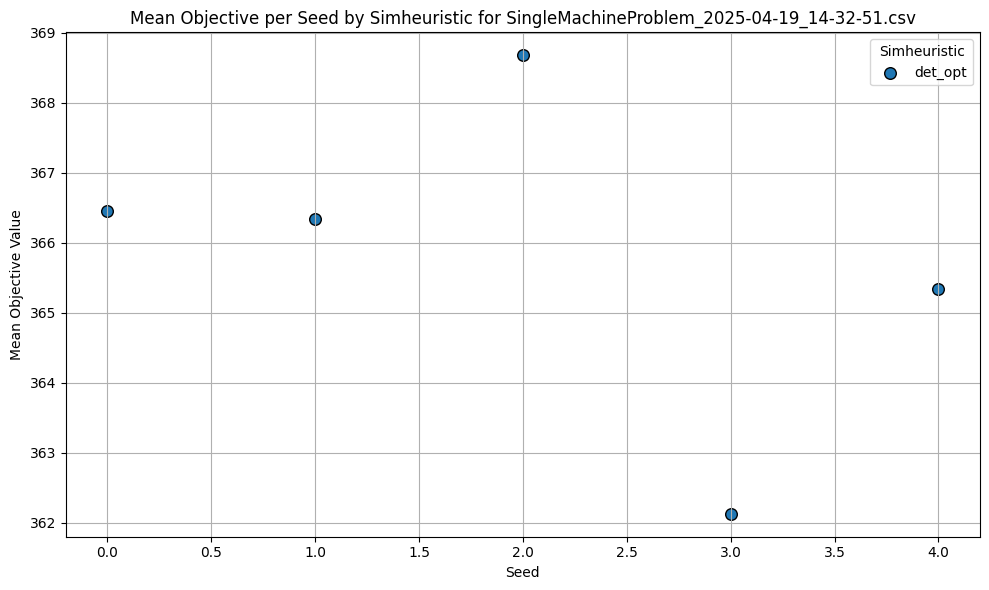

In [68]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming your DataFrame is called df
# Group by simheuristic and plot each with a different marker
fig, ax = plt.subplots(figsize=(10, 6))

# Optional: set color/marker styles for clarity
markers = ["o", "s", "^", "D", "v", "*", "x"]
colors = plt.cm.tab10.colors  # Up to 10 unique colors

for i, (simh, group) in enumerate(df.groupby("simheuristic")):
    ax.scatter(
        group["seed"],
        group["mean"],
        label=simh,
        marker=markers[i % len(markers)],
        color=colors[i % len(colors)],
        s=70,
        edgecolor="black",
    )

# Set labels and legend
ax.set_title(f"Mean Objective per Seed by Simheuristic for {file_name}")
ax.set_xlabel("Seed")
ax.set_ylabel("Mean Objective Value")
ax.legend(title="Simheuristic")
ax.grid(True)

plt.tight_layout()
plt.show()

# Significance testing

In [69]:
from itertools import combinations

import pandas as pd
from scipy.stats import ttest_rel

# Your significance level
alpha = 0.05

# Prepare data
pivot = df.pivot(index="seed", columns="simheuristic", values="mean")
methods = pivot.columns
results = pd.DataFrame(index=methods, columns=methods)

# Pairwise t-tests
p_values = {}
for m1, m2 in combinations(methods, 2):
    stat, p = ttest_rel(pivot[m1], pivot[m2])
    p_values[(m1, m2)] = p

# Multiple testing Sidak correction
n_tests = 3
alpha_correct = 1 - (1 - alpha) ** (1 / n_tests)
print(f"Corrected significance level (Sidak): {alpha_correct:.4f}")

# Fill in matrix
for m1 in methods:
    for m2 in methods:
        if m1 == m2:
            results.loc[m1, m2] = "-"
        elif (m1, m2) in p_values:
            p = p_values[(m1, m2)]
            results.loc[m1, m2] = f"{p:.4f}{'*' if p < alpha_correct else ''}"
        elif (m2, m1) in p_values:
            p = p_values[(m2, m1)]
            results.loc[m1, m2] = f"{p:.4f}{'*' if p < alpha_correct else ''}"
results

Corrected significance level (Sidak): 0.0170


simheuristic,det_opt
simheuristic,
det_opt,-


# Plotting Gantt charts

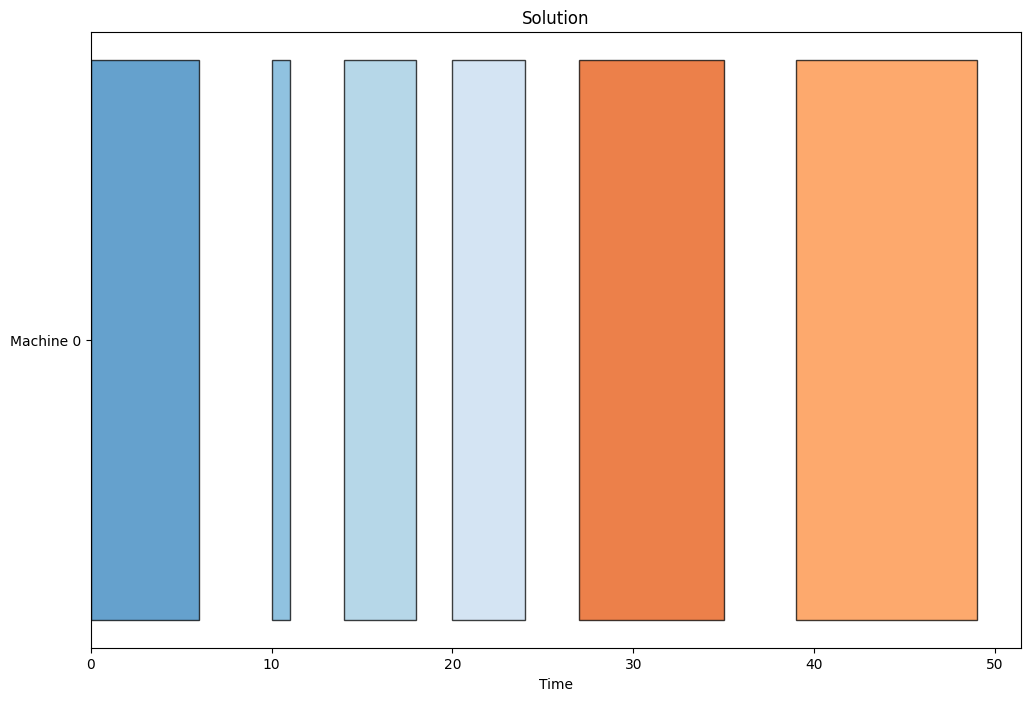

In [82]:
import numpy as np

from pyjobshop import Solution
from simpyjobshop import problems
from simpyjobshop.utils import plot_gantt_chart

seed = 0
simh = "det_opt"
filt = np.logical_and(df.seed == seed, df.simheuristic == simh)
solution_json_str = df[filt].solution.values[0]
solution = Solution.from_json_str(solution_json_str)
problem_name = file_name.split("_")[0]
problem = getattr(problems, problem_name, None)(seed)
if problem is None:
    raise ValueError(f"Unknown problem: {problem_name}")
plot_gantt_chart(solution, problem)